<a href="https://colab.research.google.com/github/nushuhu51-ux/TENSORFLOW-FULL-COURSE-FOR-DEEP-LEARNING/blob/main/02_neural_network_classification_with_tensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to neural network classification with TensorFlow

in this notebook we're going to learn how to write neural network for classifiction problems.

A classifiction is where you try to classify something as one thing or another

A few types of classification problems:
  * Binary classification
  * Multiclass classification
  * Multilabel classification

### Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles
# make 100 examples
n_samples = 1000

# Create circles
x, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
# check out features
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# check out the  labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Our data is a little hard to understand right now..let's visualize it

In [ ]:
import pandas as pd
circles = pd.DataFrame({"x0":x[:, 0], "x1":x[:, 1], "labels":y})
circles

,x0,x1,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


(<matplotlib.collections.PathCollection at 0x7d77a1f71430>,)

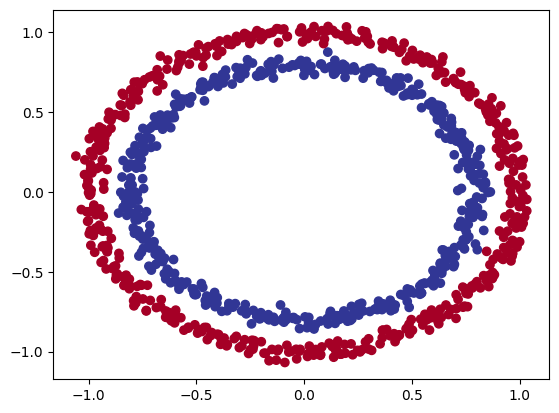

In [ ]:
# visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu),

### Input and output shapes

In [ ]:
# check the shape of our features and labels
x.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# how many samples we're working
len(x), len(y)

(1000, 1000)

In [ ]:
# view the first example of features and labels
x[17], y[17]

(array([ 0.1070617, -0.7930922]), np.int64(1))

### Steps in modeling

The steps in modeling with TensorFlow are typically:

* 1. Create or import a model
* 2. compile the model
* 3. fit the model
* 4. Evaluate the model
* 5. Tweak
* 6. Evaluate the model

In [ ]:
import tensorflow as tf
tf.__version__

'2.20.0'

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. fit the model
model_1.fit(x, y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4750 - loss: 3.8246
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5030 - loss: 0.7912
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4980 - loss: 0.7184
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5010 - loss: 0.7028
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5010 - loss: 0.6976


In [ ]:
#Let's try and improve our model by training for longer...
model_1.fit(x, y, epochs=200, verbose=1)
model_1.evaluate(x, y)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5010 - loss: 0.6957
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.6950
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4760 - loss: 0.6946
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4600 - loss: 0.6945
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4480 - loss: 0.6944
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4560 - loss: 0.6944
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4660 - loss: 0.6944
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4610 - loss: 0.6944
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4540 - loss: 0.6944
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4510 - loss: 0.6944
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4470 - loss: 0.6944
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy:

[0.6932879686355591, 0.4729999899864197]

sine we're working on a binary classification problem and our model is etting around 47% accuracy..it.s performing as if it's gussing.

so let's step things up a notch and add an extra layer.

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API , this time with 2 layers
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. fit the model
model_1.fit(x, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4660 - loss: 2.6039
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4930 - loss: 0.7454
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4980 - loss: 0.7085
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4990 - loss: 0.6994
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4910 - loss: 0.6966
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4770 - loss: 0.6956
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4740 - loss: 0.6953
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4670 - loss: 0.6952
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4610 - loss: 0.6951
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4570 - loss: 0.6951
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4540 - loss: 0.6951
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [ ]:
# evaluate our model
model_1.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4990 - loss: 0.6934


[0.6933936476707458, 0.49900001287460327]

In [ ]:
print(circles.columns)

Index(['x0', 'x1', 'labels'], dtype='object')


In [ ]:
circles["labels"].value_counts()

,count
labels,
1,500
0,500


### Improving our model

Let's look into our bag of tricks to see how we can improve our model.
 1. Create a model - we might to add more layers or increase the number of hidden units within a layer.
 2. Compiling a model - here we might to choose a difference optimization function such as Adam instead of SGD.
 3. Ftting a model - perhaps we might fit our model for more epochs.


In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API , this time with 2 layers
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. fit the model
model_3.fit(x, y, epochs=100, verbose=0)

In [ ]:
# evaluate the model
model_3.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4970 - loss: 0.6936


[0.6935943961143494, 0.4970000088214874]

To visualize our model's predictions, let's create a function 'plot_prediction_boundary()', this function will:

* Take in a trained model, features (x) and labels(y)
* Create a meshgrid of the different x values
* plot the predictions as well as a line between zones

In [ ]:
import numpy as np


def plot_decision_boundary(model, x, y):
  """
  plots the decision boundary created by a model predicting on x
  """
  # Define the axis boundary of the plot and create m meshgrid
  x_min, x_max = x[:, 0].min() - 0.1, x[:, 0].max() + 0.1
  y_min, y_max = x[:, 1].min() - 0.1, x[:, 1].max() + 0.1

  xx, yy =np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))


  # create x value
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # make predictions
  y_pred = model.predict(x_in)

  # check fpr multi-class
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # we have to reshape our prediction to get ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # plot the decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(x[:, 0], x[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


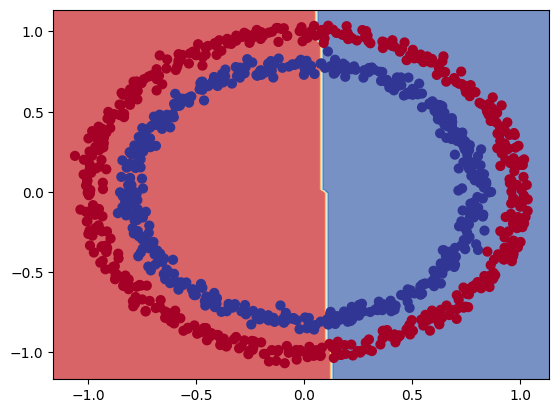

In [ ]:
# check out the prediction our model is making
plot_decision_boundary(model=model_3,
                       x=x,
                       y=y)

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API , this time with 2 layers
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

# 3. fit the model
model_3.fit(x, y, epochs=100,)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.5252 - mae: 0.5252
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5019 - mae: 0.5019
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5016 - mae: 0.5016
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5017 - mae: 0.5017
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5017 - mae: 0.5017
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5018 - mae: 0.5018
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━

### The missing pice: None linearity

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API , this time with 2 layers
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
    #tf.keras.layers.Dense(10),
    #tf.keras.layers.Dense(1)
])
# 2. compile the model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. fit the model
model_4.fit(x, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4830 - loss: 6.3476
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4820 - loss: 6.3293
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 6.3395
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 6.3389
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 6.3384
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 6.3378
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 6.3372
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 6.3367
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4810 - loss: 6.3266
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4810 - loss: 6.3141
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4810 - loss: 6.3130
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

(<matplotlib.collections.PathCollection at 0x7d772e960620>,)

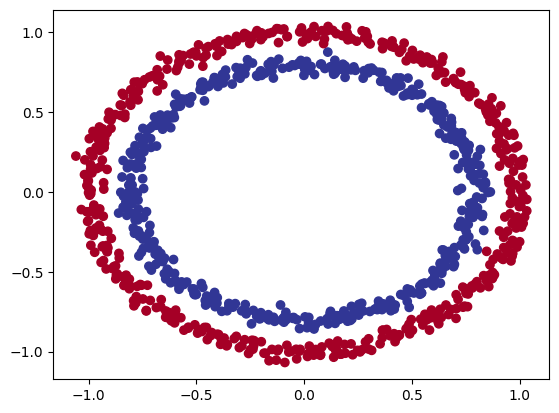

In [ ]:
# check out our data
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu),

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


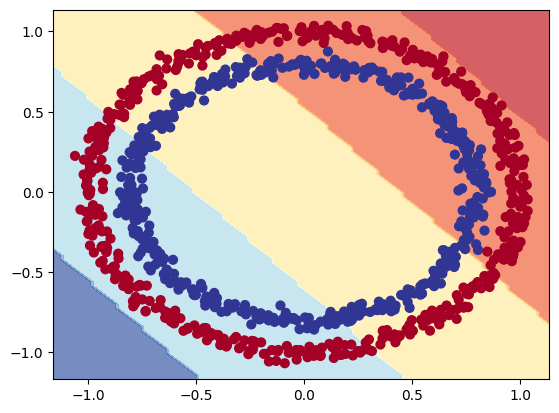

In [ ]:
# check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       x=x,
                       y=y)

Let's try build our first neural network with a non-linear activation function.

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequantial API , this time with 2 layers
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
    #tf.keras.layers.Dense(10),
    #tf.keras.layers.Dense(1)
])
# 2. compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. fit the model
history = model_5.fit(x, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5000 - loss: 4.5150
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 4.3546
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 4.2136
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 4.0985
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 3.9142
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 3.7896
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 3.6084
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 3.4136
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 3.1855
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 2.8391
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 2.5169
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [ ]:
# Time to replicate the multilayer neural networks from TensorFlow Playground

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)   # FIXED
])

# 2. Compile the model
model_6.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# 3. Fit the model
history = model_6.fit(
    x,
    y,
    epochs=100
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5000 - loss: 1.2280
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.9984
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4900 - loss: 0.8649
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3950 - loss: 0.8122
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3150 - loss: 0.7918
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3330 - loss: 0.7786
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3600 - loss: 0.7684
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3610 - loss: 0.7599
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3720 - loss: 0.7524
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3800 - loss: 0.7456
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 0.7394
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [ ]:
# evaluate the model
model_6.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9070 - loss: 0.3407


[0.34073975682258606, 0.9070000052452087]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


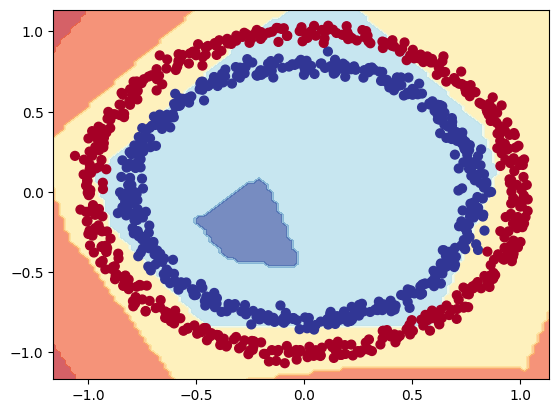

In [ ]:
# how to our model prediction looks?
plot_decision_boundary(model_6, x, y)

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# 3. Fit the model
history = model_7.fit(
    x,
    y,
    epochs=100
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5040 - loss: 0.6876
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5030 - loss: 0.6862
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5140 - loss: 0.6851
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5280 - loss: 0.6841
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5360 - loss: 0.6831
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5460 - loss: 0.6820
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5490 - loss: 0.6810
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5590 - loss: 0.6799
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5720 - loss: 0.6788
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5850 - loss: 0.6777
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5970 - loss: 0.6766
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [ ]:
# evaluate our model
model_7.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9910 - loss: 0.2606


[0.2606159448623657, 0.9909999966621399]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification


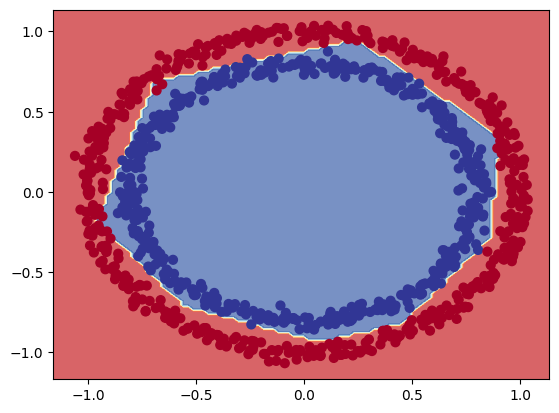

In [ ]:
# Let's visualize our incrideble  model_7
plot_decision_boundary(model_7, x, y)

**Note:** The linear combination of **linear (straight line) ad non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

Now we've discussed the concept of linear and non-linear functions(or lines), let's see them in action.

In [ ]:
# Let as create a toy a tensor
A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

([<matplotlib.lines.Line2D at 0x7d76943e56d0>],)

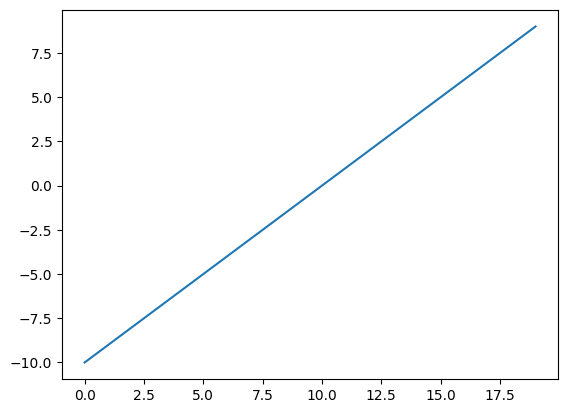

In [ ]:
# visualize our toy tensor
plt.plot(A),

In [ ]:
# let's start by replicating sigmoid = sigmoid(x) = 1/ (1 + exp(-x))
def sigmoid(x):
  return 1 / (1 + tf.exp(-x))

# use the sigmoid function on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397868e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726230e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105854e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

([<matplotlib.lines.Line2D at 0x7d7755c58ce0>],)

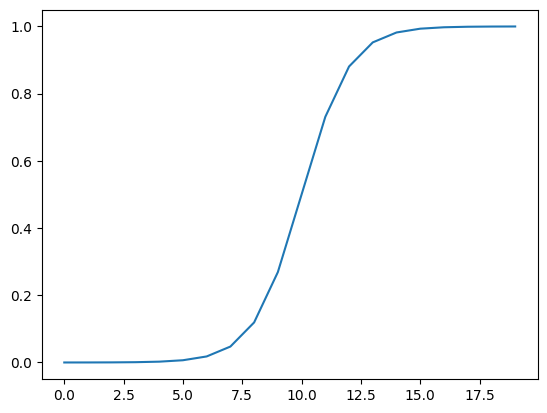

In [ ]:
# plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A)),

In [ ]:
# Let's recreate the relu function
def relu(x):
  return tf.maximum(0, x)

# pass our toy tensor to our custom relu function
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

In [ ]:
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

([<matplotlib.lines.Line2D at 0x7d76944332f0>],)

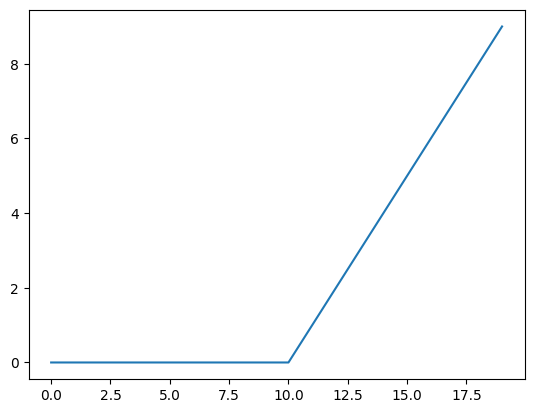

In [ ]:
# plot ReLU -modified tensor
plt.plot(relu(A)),

In [ ]:
# Let's try the linear activation function
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

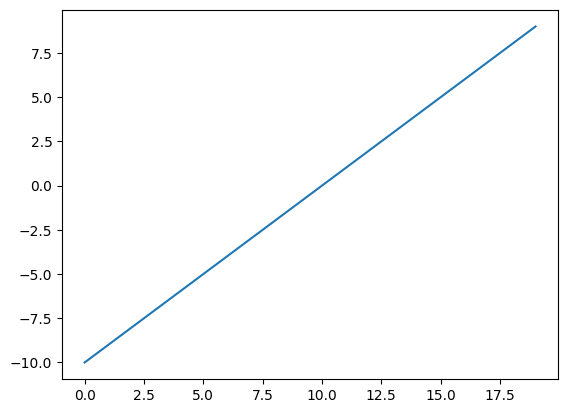

In [ ]:
# Does the linear activation function change anything?
plt.plot(tf.keras.activations.linear(A))

In [ ]:
# Does A even change?
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

### Evaluating and improving our model

so far we've been training and testing on the same dataset...


In [ ]:
# check how many exaples we have
len(x)

1000

In [ ]:
# split into train and test sets
x_train, y_train = x[:800], y[:800]
x_test, y_test = x[800:], y[800:]
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((800, 2), (800,), (200, 2), (200,))

In [ ]:
# let's recreate a model to fit on the training data and evaluate our model


# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")   # FIXED
])

# 2. Compile the model
model_8.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3. Fit the model
history = model_8.fit(
    x_train,
    y_train,
    epochs=25
)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5025 - loss: 0.6924
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5713 - loss: 0.6791
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6087 - loss: 0.6679
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6762 - loss: 0.6484
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7325 - loss: 0.6204
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7937 - loss: 0.5808
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8263 - loss: 0.5289
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8425 - loss: 0.4776
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8838 - loss: 0.4271
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9087 - loss: 0.3777
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9425 - loss: 0.3300
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - lo

In [ ]:
# evaluate our model
model_8.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9850 - loss: 0.0907


[0.09067056328058243, 0.9850000143051147]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


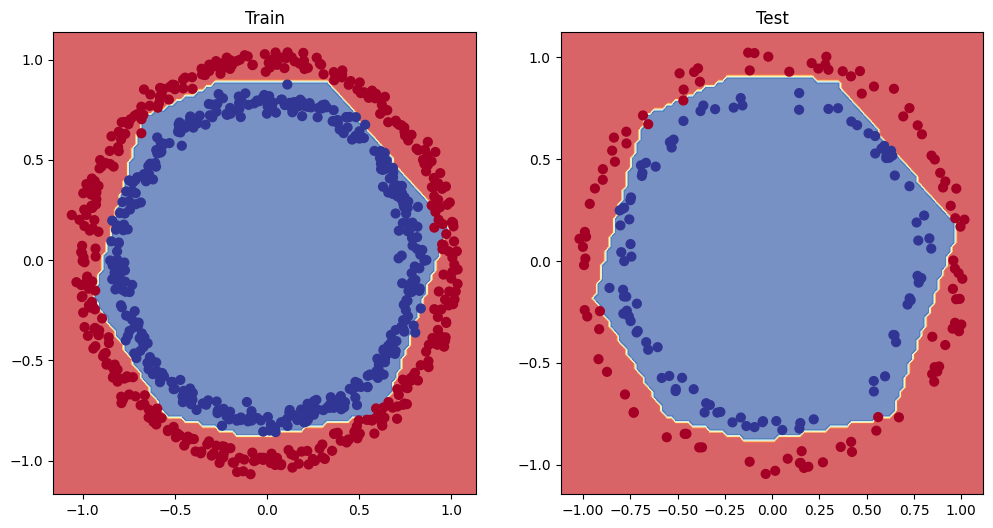

(None,)

In [ ]:
# plot the decision boundary for the training and testset
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, x=x_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, x=x_test, y=y_test)
plt.show(),

### Plot the loss Curve

In [ ]:
pd.DataFrame(history.history)

,accuracy,loss
0,0.50250,0.692434
1,0.57125,0.679111
2,0.60875,0.667913
3,0.67625,0.648388
4,0.73250,0.620429
5,0.79375,0.580764
6,0.82625,0.528917
7,0.84250,0.477578
8,0.88375,0.427137
9,0.90875,0.377666


(Text(0.5, 1.0, 'model_8_loss curves'),)

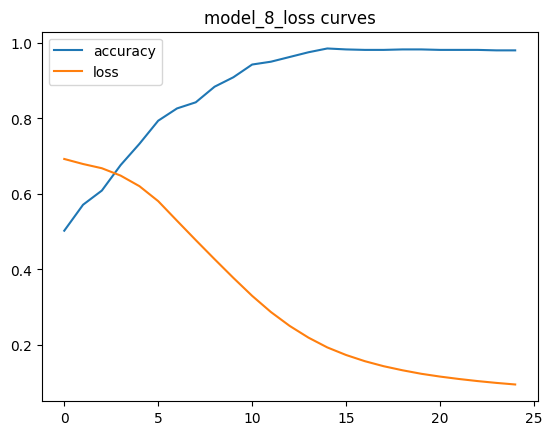

In [ ]:
# plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("model_8_loss curves"),

**Note:** For many problems, the loss function going down means the model is improving (the predictions it's making are getting closer to the ground truth labels).

### Finding the best learning rate

To find the ideal learning rate (the learning rate where the loss decreases the most during training) we're going to use the following steps:
* A learning rate **callbacks** - you can think of a callback as an extra pice of functionality, you can add to your **while** it's training.
* Another model(we could use the same one as above , but we're practicing building models here)
* A modified loss curve plot.

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")   # FIXED
])

# 2. Compile the model
model_9.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer= "Adam",
    metrics=["accuracy"]
)
# creae a learning rate callback function
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10** (epoch/ 20))

# 3. Fit the model
history_9 = model_9.fit(
    x_train,
    y_train,
    epochs= 100,
    callbacks = [lr_scheduler]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4988 - loss: 0.6917 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4963 - loss: 0.6916 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4963 - loss: 0.6916 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4963 - loss: 0.6915 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4988 - loss: 0.6914 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4975 - loss: 0.6914 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4950 - loss: 0.6913 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6912 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6911 - learning_

<Axes: xlabel='epochs'>

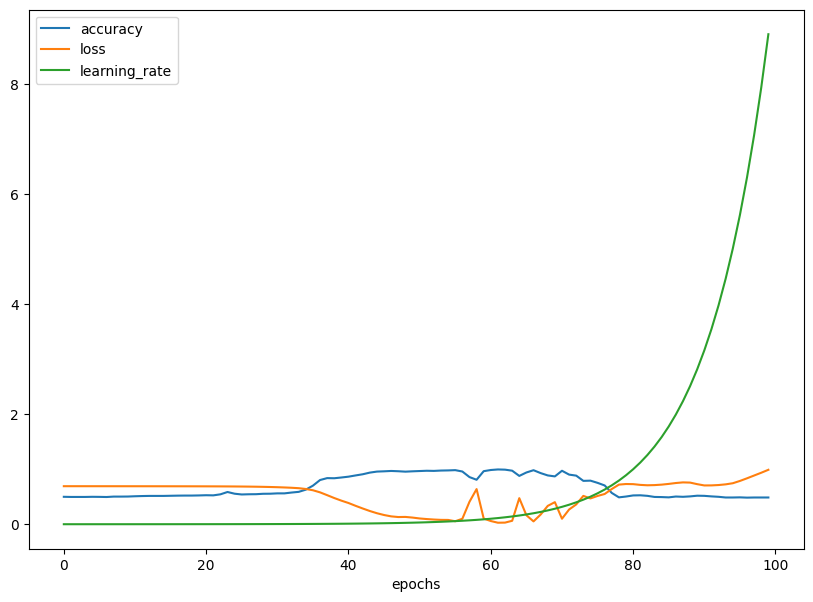

In [ ]:
# check out the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs Loss')

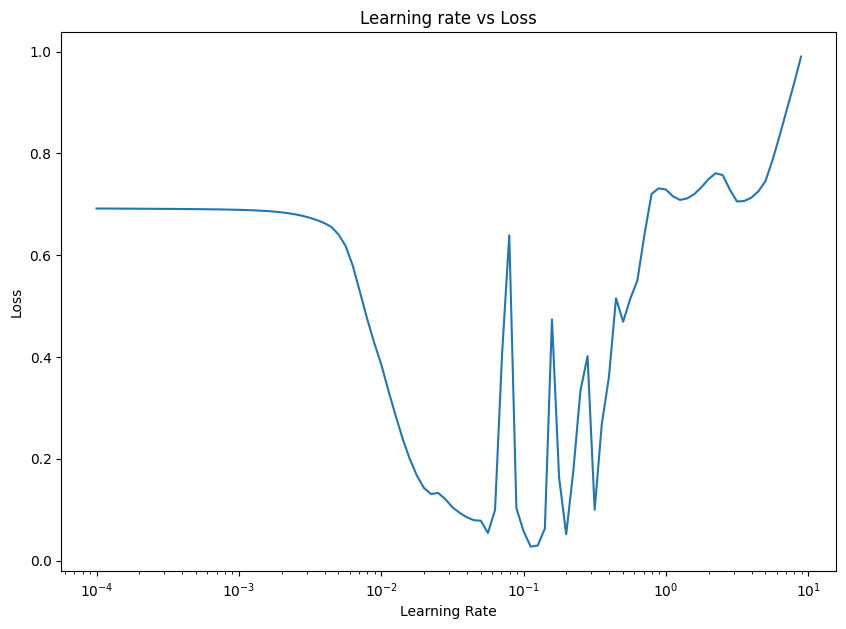

In [ ]:
# plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs Loss")

In [ ]:
# Let's try using a higher *ideal* learning rates with the same model

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")   # FIXED
])

# 2. Compile the model
model_10.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics=["accuracy"]
)
# creae a learning rate callback function
#lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10** (epoch/ 20))

# 3. Fit the model
history_10= model_10.fit(
    x_train,
    y_train,
    epochs= 20,
    #callbacks = [lr_scheduler]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5512 - loss: 0.6855
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5625 - loss: 0.6725
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6087 - loss: 0.6512
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7237 - loss: 0.6074
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7800 - loss: 0.5457
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8263 - loss: 0.4825
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8875 - loss: 0.4148
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9362 - loss: 0.3491
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9650 - loss: 0.2913
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.2466
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9712 - loss: 0.2135
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9675 - lo

In [ ]:
# Evaluate model 10 on the test dataset
model_10.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9750 - loss: 0.1043


[0.10433613508939743, 0.9750000238418579]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


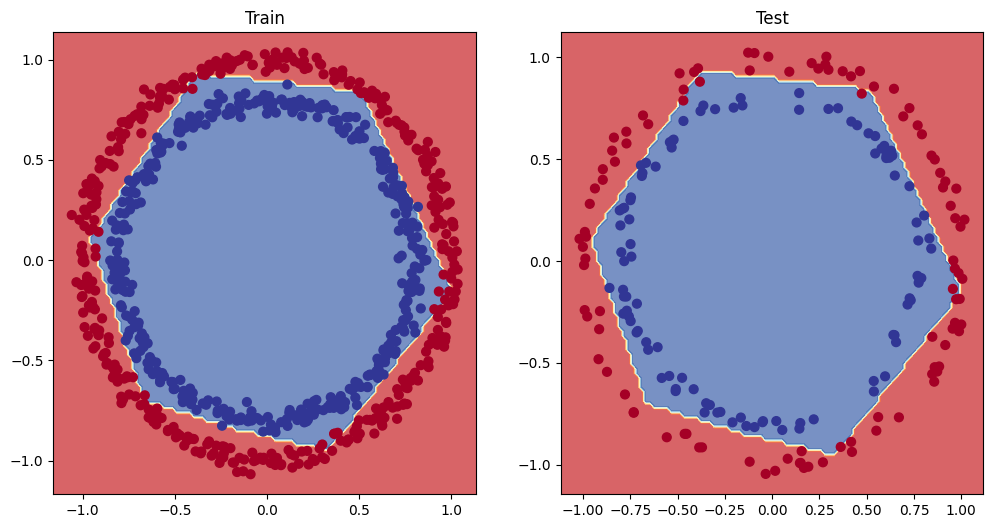

(None,)

In [ ]:
# plot the decision boundary for the training and testset
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_10, x=x_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_10, x=x_test, y=y_test)
plt.show(),

### More Classification evaluation methods

Alongside visualizing our models results as much as possible, there are a handful of other classification evaluation methods & metrics you should be familiar with:
* Accuracy
* Recall
* Precision
* F1-score
* Confusion matrix
8 Classification report (from scikt-learn)

In [ ]:
# check the accuracy of our model
loss, accuracy = model_10.evaluate(x_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the testset: {(accuracy*100):.2f}% ")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9750 - loss: 0.1043 
Model loss on the test set: 0.10433613508939743
Model accuracy on the testset: 97.50% 


In [ ]:
# Make predictions
y_preds = model_10.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


How about the confusion matrix?

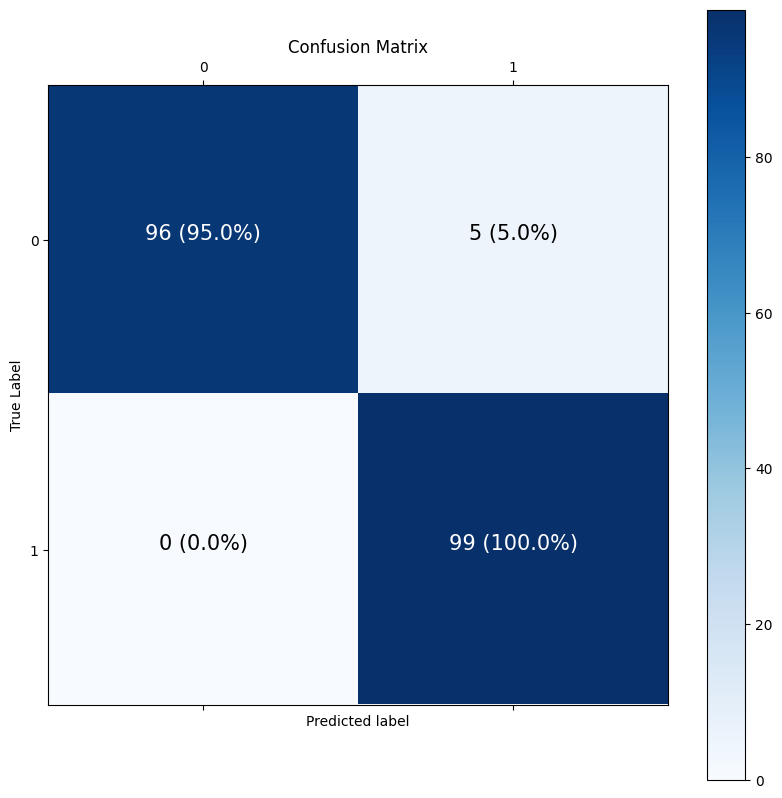

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

figsize = (10, 10)

# Create a confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

n_classes = cm.shape[0]
# Let's prettify it
fig, ax=plt.subplots(figsize=figsize)
# create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# create classes
classes = False
if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

# Labe the axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted label",
       ylabel="True Label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

# plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size=15)


### Working with a larger example(Multiclassclasification)

when you  have more than two classes as an option, it's known as **multi-classclasification**.
* This means if you have 3 different classes,it's multi-class classification.
* It also means if you have 100 different classes,it's multi-class classification.

To practice multi-class classification, we 're going to build a neula network to classify images of different item of clothing.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and testing sets for as
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# show the first training example
print(f"Training sample:\n {train_data[0]}\n")
print(f"Training labels:\n {train_labels[0]}\n")

Training sample:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1 

In [ ]:
# check the shape of a single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

(<matplotlib.image.AxesImage at 0x7d767c4a2f90>,)

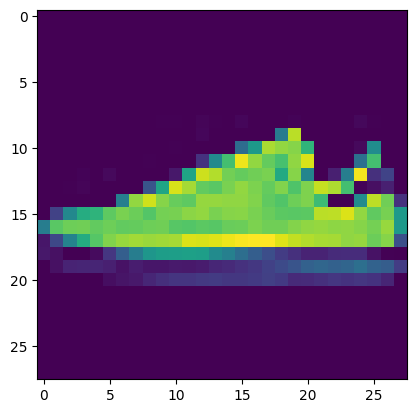

In [ ]:
# plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[6]),

In [ ]:
# check out sample labels
train_labels[7]

np.uint8(2)

In [ ]:
# create a small list so we can index onto our training labels so they 're human readables
class_name = ["T-shirt/top", "Trouser", "pullover", "Dress", "coat", "sandal", "shirt", "sneaker", "bag", "Ankle boot"]
len(class_name)

10

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

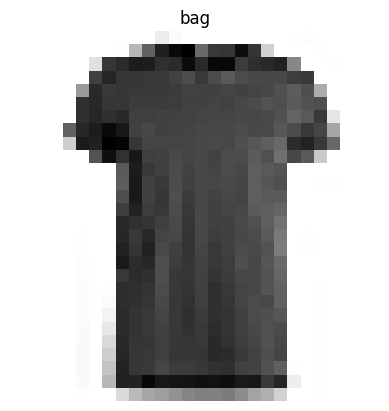

In [ ]:
# plot an example image and its label
index_of_choice = 200
plt.imshow(train_data[17], cmap=plt.cm.binary)
plt.title(class_name[train_labels[index_of_choice]])
plt.axis("off")

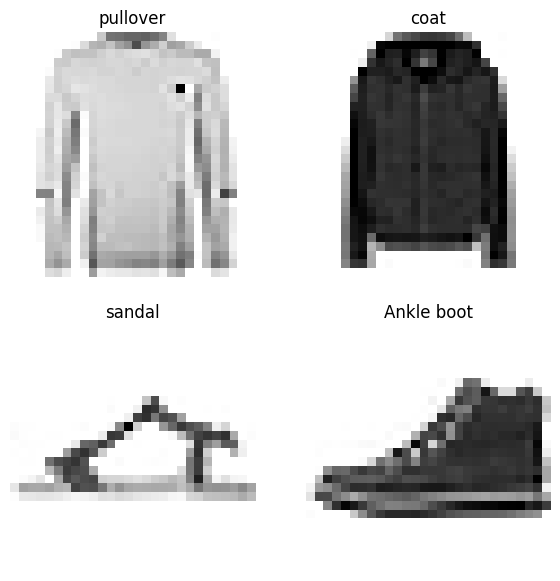

In [ ]:
# plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7, 7))
for i in range(4):
  ax = plt.subplot(2, 2, i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_name[train_labels[rand_index]])
  plt.axis("off")

### Building a multi-class classification Model

for our multi-class classification model, we can use a similar architecture to our binary classifier, however, we 're going to have to tweak a few things:
* input shape = 28 x 28 (the shape of one image)
* output shape = 10 (one per class of clothing)
* Loss function = tf.keras.loss.CatagoricalCrossEntropy()
* Output layer activation = Softmax(not sigmoid)
* If your labels are one-hot encoded, use CatagoricalCrossentropy()
* If your labels are integer form use SparseCategoricalCrossEntropy()

In [ ]:
tf.one_hot(train_labels[:10], depth=10)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [ ]:
# our data needs to be flattened (from 28*28 to None, 784)
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28, 28))])
flatten_model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [ ]:

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")   # FIXED
])

# 2. Compile the model
model_11.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics=["accuracy"])

# 3. Fit the model
history_11= model_11.fit(
    train_data,
    tf.one_hot(train_labels, depth=10),
    epochs= 10,
    validation_data = (test_data, tf.one_hot(test_labels, depth=10))
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1007 - loss: 2.3736 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1012 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 -

In [ ]:
# check the model summary
model_11.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [ ]:
# check the min and max value of the training data
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Neural networks prefer data to be scaled (or normalized), this means they like to have the numbers in the tensors they try to find patterns between 0 & 1.

In [ ]:
# we can get our training and testing data between 0 & 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

# check the min and max values of the scaled training data
train_data_norm.min(), train_data_norm.max()


(np.float64(0.0), np.float64(1.0))

In [ ]:
# now our data is normalized, let's build a model to find a pattern in it


# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")   # FIXED
])

# 2. Compile the model
model_12.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics=["accuracy"])

# 3. Fit the model
norm_history_12= model_12.fit(
    train_data,
    train_labels,
    epochs= 10,
    validation_data = (test_data, test_labels)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1012 - loss: 2.4334 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accuracy: 0.1000 - val_loss: 2.3061
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1013 - loss: 2.3051 - val_accurac

**Note:** Neural networks tend to prefer in numerical form as well as scaled/normalized (numberes between 0 & 1).

<Axes: title={'center': 'Normalized Data'}>

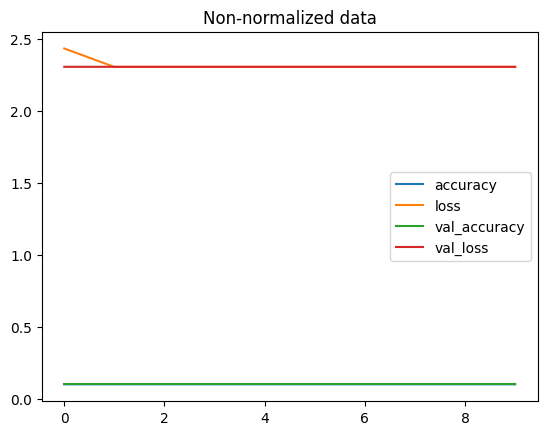

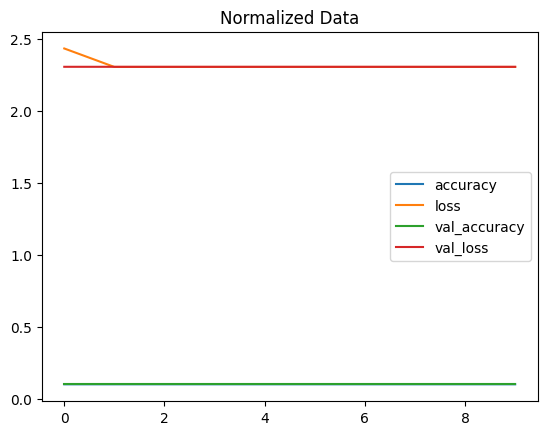

In [ ]:
import pandas as pd
# plot non-normalized data loss curves
pd.DataFrame(norm_history_12.history).plot(title="Non-normalized data")
# plot normalized data loss curves
pd.DataFrame(norm_history_12.history).plot(title="Normalized Data")

### Finding the Ideal learning rate

In [ ]:
# now our data is normalized, let's build a model to find a pattern in it


# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")   # FIXED
])

# 2. Compile the model
model_13.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics=["accuracy"])

# creating the learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 *10**(epoch/20))

# 3. Fit the model
norm_history_13= model_13.fit(
    train_data,
    train_labels,
    epochs= 40,
    validation_data = (test_data, test_labels),
    callbacks = [lr_scheduler]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1963 - loss: 2.1350 - val_accuracy: 0.2678 - val_loss: 1.8536 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2765 - loss: 1.7769 - val_accuracy: 0.2819 - val_loss: 1.7328 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2893 - loss: 1.7210 - val_accuracy: 0.3122 - val_loss: 1.6925 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2969 - loss: 1.7028 - val_accuracy: 0.3245 - val_loss: 1.6802 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3150 - loss: 1.6223 - val_accuracy: 0.3358 - val_loss: 1.5402 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3254 - loss: 1.5273 - val_accuracy: 0.3145 - val_loss: 1.5410 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3284 - 

Text(0.5, 1.0, 'Finding the ideal learing rate')

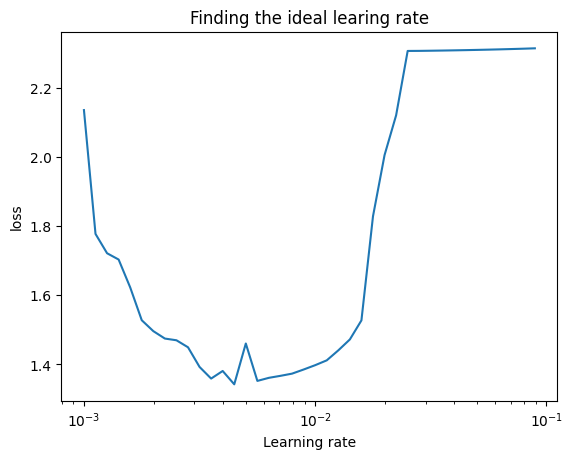

In [ ]:
# plot the learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt

lrs = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs, norm_history_13.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("loss")
plt.title("Finding the ideal learing rate")

In [ ]:
# Let's refit a model with the ideal learning rate

# now our data is normalized, let's build a model to find a pattern in it


# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_14.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"])

# creating the learning rate callback
#lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 *10**(epoch/20))

# 3. Fit the model
norm_history_14= model_14.fit(
    train_data,
    train_labels,
    epochs= 20,
    validation_data = (test_data, test_labels)
    #callbacks = [lr_scheduler]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0978 - loss: 2.3613 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1022 - loss: 2.2979 - val_accuracy: 0.1146 - val_loss: 2.2704
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1191 - loss: 2.2599 - val_accuracy: 0.1311 - val_loss: 2.2337
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1489 - loss: 2.1902 - val_accuracy: 0.1753 - val_loss: 2.1242
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2043 - loss: 1.9496 - val_accuracy: 0.2124 - val_loss: 1.7788
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2573 - loss: 1.7324 - val_accuracy: 0.2892 - val_loss: 1.6769
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2855 - loss: 1.6652 - val_accuracy: 0.2968 - val_loss: 1.6329
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2897 - loss: 1.6322 - 

### Evaluating our multi-class classification model


To evaluate our multi-class classification model we could:

* Evaluate its performance using other classification metrics (such as a confusion matrix)
* Asses some of its predictions (by training it for longer or changing the architecture)
* save and export it for use in an application

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

figsize = (10, 10)

def make_confusion_matrix(y_true, y_pred, classes=None, figsiz = (10, 10), text_size=15):

  # Create a confusion matrix
  cm = confusion_matrix(y_true, tf.round(y_pred))
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

  n_classes = cm.shape[0]
  # Let's prettify it
  fig, ax=plt.subplots(figsize=figsize)
  # create a matrix plot
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  # set labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Labe the axes
  ax.set(title="Confusion Matrix",
        xlabel="Predicted label",
        ylabel="True Label",
        xticks=np.arange(text_size),
        yticks=np.arange(text_size),
        xticklabels=labels,
        yticklabels=labels)

  # Set threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            size=text_size)

In [ ]:
# make some predictions with our model
y_probs = model_14.predict(test_data)

# view the first 5 predictions
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.4633323e-22, 5.5537001e-29, 0.0000000e+00, 7.0556119e-25,
        1.7453245e-36, 5.8965806e-02, 1.7348403e-32, 7.0786136e-01,
        2.7061869e-05, 2.3314580e-01],
       [1.4003108e-01, 1.4117438e-01, 1.4395730e-01, 1.4193206e-01,
        1.4104867e-01, 8.3237356e-03, 1.4585523e-01, 2.2826858e-03,
        1.3537331e-01, 2.1488209e-05],
       [1.4003108e-01, 1.4117438e-01, 1.4395730e-01, 1.4193206e-01,
        1.4104867e-01, 8.3237356e-03, 1.4585523e-01, 2.2826858e-03,
        1.3537331e-01, 2.1488209e-05],
       [1.4003108e-01, 1.4117438e-01, 1.4395730e-01, 1.4193206e-01,
        1.4104867e-01, 8.3237356e-03, 1.4585523e-01, 2.2826858e-03,
        1.3537331e-01, 2.1488209e-05],
       [1.4003108e-01, 1.4117438e-01, 1.4395730e-01, 1.4193206e-01,
        1.4104867e-01, 8.3237356e-03, 1.4585523e-01, 2.2826858e-03,
        1.3537331e-01, 2.1488209e-05]], dtype=float32)

In [ ]:
y_probs[0], tf.argmax(y_probs[0]), class_name[tf.argmax(y_probs[0])]

(array([1.4633323e-22, 5.5537001e-29, 0.0000000e+00, 7.0556119e-25,
        1.7453245e-36, 5.8965806e-02, 1.7348403e-32, 7.0786136e-01,
        2.7061869e-05, 2.3314580e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=7>,
 'sneaker')

In [ ]:
# convert all of prediction probabilities into integeres
y_preds = y_probs.argmax(axis=1)

# view the first 10 prediction labels
y_preds[:10]

array([7, 6, 6, 6, 6, 6, 6, 6, 5, 7])

In [ ]:
model_14.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [ ]:
from tensorflow.keras.datasets import mnist

(_, _), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_test = x_test / 255.0

In [ ]:
import numpy as np

print(np.unique(y_preds))

[8]


In [ ]:
# Let's refit a model with the ideal learning rate

# now our data is normalized, let's build a model to find a pattern in it


# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_14.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"])

# creating the learning rate callback
#lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 *10**(epoch/20))

# 3. Fit the model
norm_history_14= model_14.fit(
    train_data,
    train_labels,
    epochs= 20,
    validation_data = (test_data, test_labels)
    #callbacks = [lr_scheduler]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1208 - loss: 2.3347 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1012 - loss: 2.3038 - 

In [ ]:
# make some predictions with our model
y_probs = model_14.predict(test_data)

# view the first 5 predictions
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.09637902, 0.09901021, 0.10283583, 0.09504395, 0.09394739,
        0.09895585, 0.11073126, 0.10878382, 0.09840149, 0.0959112 ],
       [0.09637902, 0.09901021, 0.10283583, 0.09504395, 0.09394739,
        0.09895585, 0.11073126, 0.10878382, 0.09840149, 0.0959112 ],
       [0.09637902, 0.09901021, 0.10283583, 0.09504395, 0.09394739,
        0.09895585, 0.11073126, 0.10878382, 0.09840149, 0.0959112 ],
       [0.09637902, 0.09901021, 0.10283583, 0.09504395, 0.09394739,
        0.09895585, 0.11073126, 0.10878382, 0.09840149, 0.0959112 ],
       [0.09637902, 0.09901021, 0.10283583, 0.09504395, 0.09394739,
        0.09895585, 0.11073126, 0.10878382, 0.09840149, 0.0959112 ]],
      dtype=float32)

In [ ]:
# convert all of prediction probabilities into integeres
y_preds = y_probs.argmax(axis=1)

# view the first 10 prediction labels
y_preds[:10]

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6])

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict
y_preds = model_14.predict(x_test)

# Convert probabilities → class labels
y_preds = np.argmax(y_preds, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_preds)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[   0    0    0    0    0    0    0  980    0    0]
 [   0    0    0    0    0    0    0 1135    0    0]
 [   0    0    0    0    0    0    0 1032    0    0]
 [   0    0    0    0    0    0    0 1010    0    0]
 [   0    0    0    0    0    0    0  982    0    0]
 [   0    0    0    0    0    0    0  892    0    0]
 [   0    0    0    0    0    0    0  958    0    0]
 [   0    0    0    0    0    0    0 1028    0    0]
 [   0    0    0    0    0    0    0  974    0    0]
 [   0    0    0    0    0    0    0 1009    0    0]]


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Make sure input shape is correct BEFORE predict
x_test = x_test.reshape(-1, 28, 28)   # or (-1, 784) depending on model

# Predict
y_preds = model_14.predict(x_test)

# Convert to class labels
y_preds = np.argmax(y_preds, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_preds)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[   0    0    0    0    0    0    0  980    0    0]
 [   0    0    0    0    0    0    0 1135    0    0]
 [   0    0    0    0    0    0    0 1032    0    0]
 [   0    0    0    0    0    0    0 1010    0    0]
 [   0    0    0    0    0    0    0  982    0    0]
 [   0    0    0    0    0    0    0  892    0    0]
 [   0    0    0    0    0    0    0  958    0    0]
 [   0    0    0    0    0    0    0 1028    0    0]
 [   0    0    0    0    0    0    0  974    0    0]
 [   0    0    0    0    0    0    0 1009    0    0]]


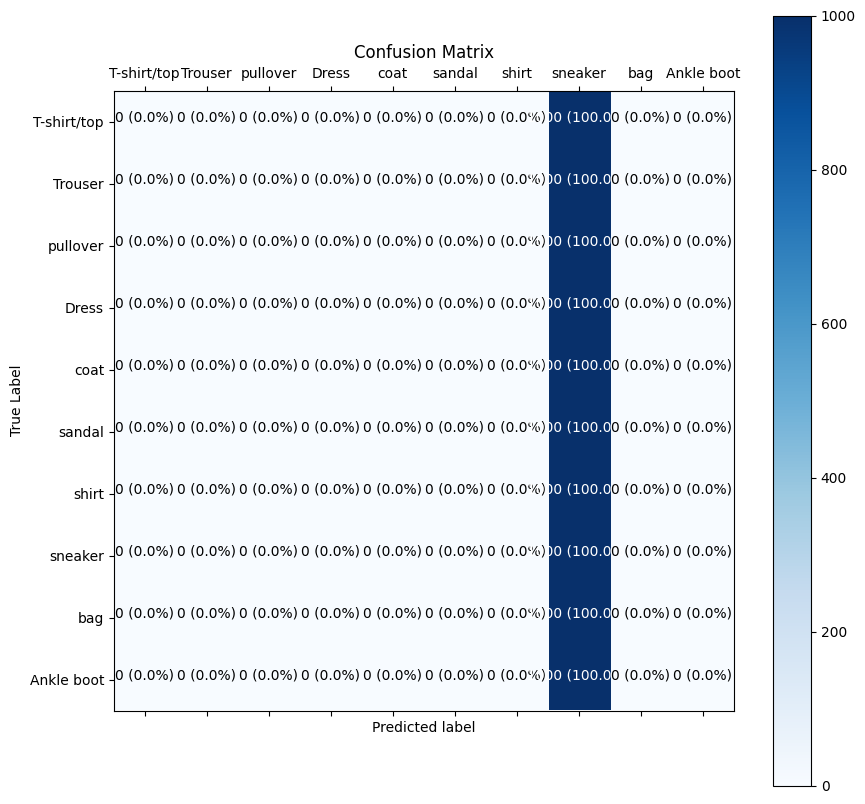

In [ ]:
# make a prettier confusion matrix
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_name,

                      text_size=10)

Asses some of its predictions (by training it for longer or changing the architecture).

How about we create a fun little function for:
* plot a random image
* make a prediction on said image
* Label the plot with truth label & the predicted label

In [ ]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt

def plot_random_image(model, images, true_labels, classes):
    i = random.randint(0, len(images) - 1)

    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1, 28, 28), verbose=0)

    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]

    plt.imshow(target_image, cmap=plt.cm.binary)

    color = "green" if pred_label == true_label else "red"

    plt.xlabel(
        "Pred: {} ({:.2f}%) (True: {})".format(
            pred_label,
            float(100 * tf.reduce_max(pred_probs)),
            true_label
        ),
        color=color
    )

    plt.axis(False)
    plt.show()

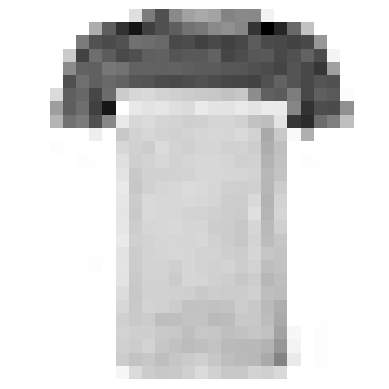

In [ ]:
# check out a random image as well as its prediction
plot_random_image(model = model_14,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_name)